In [8]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'S2'
manifold = get_manifold(manifold_type)

In [9]:

num_modes = 2; tau2 = 0.1; sigma2 = .152
# num_modes = 4; tau2 = 0.025; sigma2 = .1
# num_modes = 5; tau2 = 5e-2; sigma2 = .15
# num_modes = 10; tau2 = 1e-3; sigma2 = .1
G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 
# tau2 = 1e-4
# G = lambda n: equator_sampler(manifold_type, n, tau2)

In [10]:
n_samples = 5000
Theta = G(n_samples)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

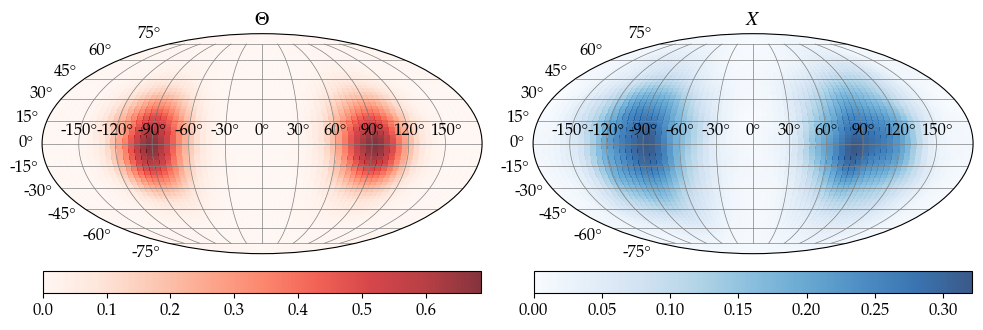

In [11]:
if True:
    fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection': 'mollweide'})
    grid_resolution = 75
    grid, grid_theta, grid_phi = S2grid(grid_resolution)
    densities = [kernel_density_estimate('S2', data, grid, 50)[1].reshape(grid_resolution, grid_resolution) for data in [Theta, X]]
    vmax = None #max([d.max() for d in densities])
    for hat_f, ax, title, cmap in zip(densities, axs, ['$\\Theta$', '$X$', 'Denoised $X$'], ['Reds', 'Blues', 'Greens']):
        im = ax.pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f,
                        alpha=0.8, shading='auto', cmap=cmap, vmin=0, vmax=vmax)
        fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
        ax.grid(True, color='gray', lw=0.5)
        ax.set_title(title)
    plt.tight_layout(); plt.show()

Folds: 100%|██████████| 10/10 [00:39<00:00,  3.95s/it]


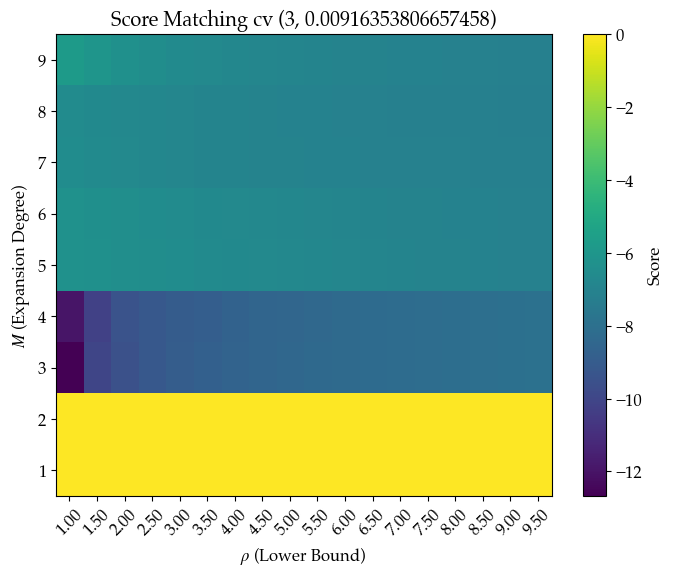

In [12]:
M_grid=np.arange(1, 10)
rhoperc_grid = np.arange(1,10,0.5)
criterion = 'AIC'
params, scores = scoreMatchingKFoldCV(manifold_type, X, M_grid, rhoperc_grid, n_splits=10, return_scores = True, random_state=42)
plot_cv_scores(scores[criterion], M_grid, rhoperc_grid, title=f"Score Matching cv {params[criterion]}")
M, rho = params[criterion]

In [13]:
# --- denoisers
delta = denoiser(manifold_type, X, M, rho, sigma2, X)
num_oracle_samples = 10000
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, G, 10000)
# --- losses
loss_N = sq_loss(manifold, X, Theta)
loss_T = sq_loss(manifold, delta, Theta) 
loss_oracle_T = sq_loss(manifold, oracle_delta_T, Theta) 

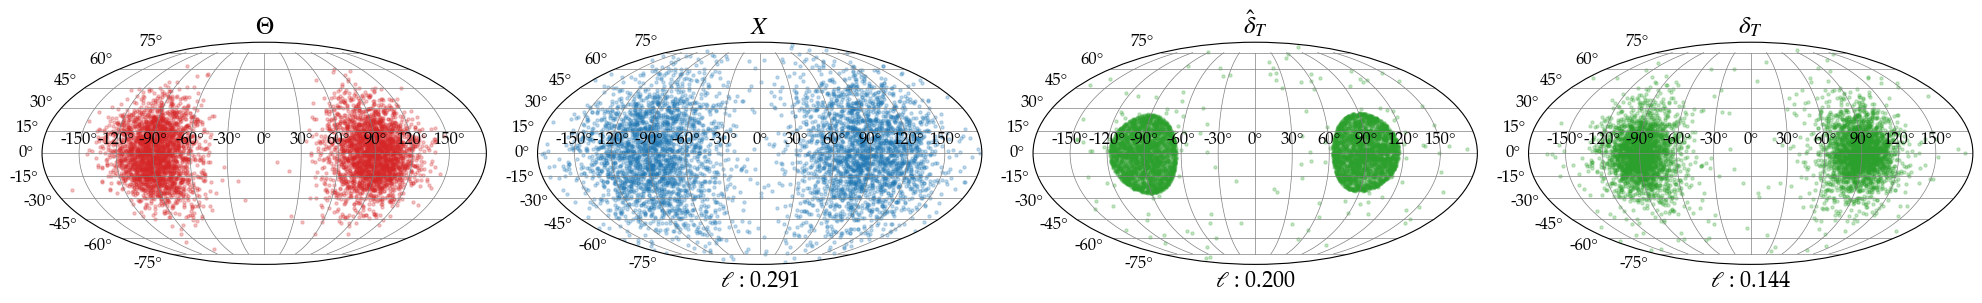

Excess loss:  0.05631547745025639


In [14]:
if True:
    fig, axs = plt.subplots(1, 4, figsize=(20, 5), 
                            subplot_kw={'projection': 'mollweide'}
                            )

    S2scatter(Theta, axs[0], color='C3', alpha=0.25)
    axs[0].set_title(r'$\Theta$', fontsize=18)

    S2scatter(X, axs[1], color='C0', alpha=0.25)
    axs[1].set_title(r'$X$', fontsize=18)
    axs[1].set_xlabel(rf'$\ell$ : {loss_N:.3f}', fontsize=16)

    S2scatter(delta, axs[2], color='C2', alpha=0.25)
    axs[2].set_title(r'$\hat\delta_T$', fontsize=18)
    axs[2].set_xlabel(rf'$\ell$ : {loss_T:.3f}', fontsize=16)

    S2scatter(oracle_delta_T, axs[3], color='C2', alpha=0.25)
    axs[3].set_title(r'$\delta_T$', fontsize=18)
    axs[3].set_xlabel(rf'$\ell$ : {loss_oracle_T:.3f}', fontsize=16)

    plt.savefig('denoising_S2.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()
print('Excess loss: ', loss_T - loss_oracle_T)

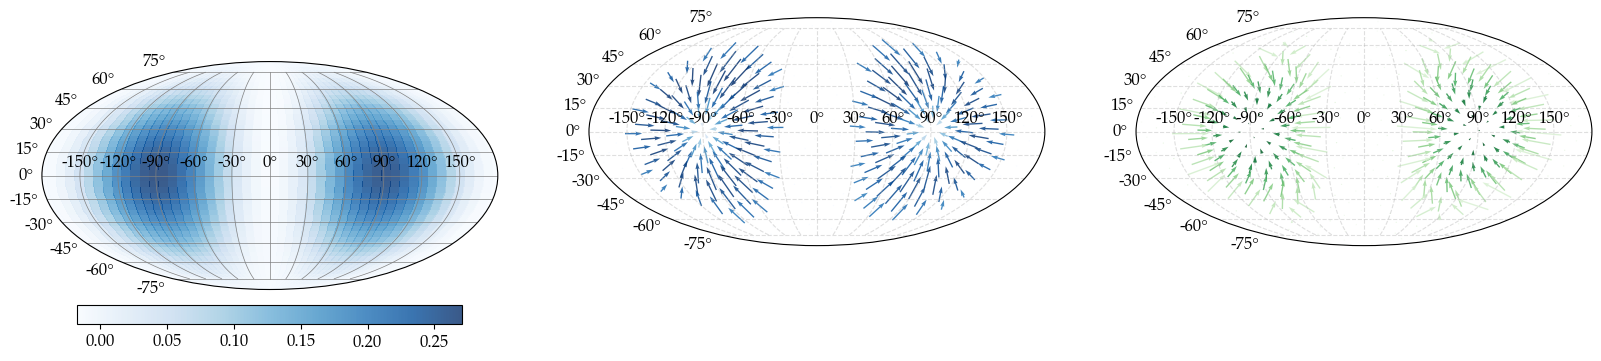

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), 
                        subplot_kw={'projection': 'mollweide'}
                        ); 
grid_resolution = 50
grid, grid_theta, grid_phi = S2grid(grid_resolution)
_, hat_f, hat_grad_f, = density_estimate('S2', X, M, grid)
hat_grad_f = np.where(hat_f[:, None] > rho, hat_grad_f, np.zeros_like(hat_grad_f))
im = axs[0].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Blues')
fig.colorbar(im, ax= axs[0], orientation='horizontal', fraction=0.05, pad=0.04)
axs[0].grid(True, color='gray', lw=0.5)


grid_resolution = 20
grid, grid_theta, grid_phi = S2grid_fib(grid_resolution)
_, hat_f, hat_grad_f, = density_estimate('S2', X, M, grid)
hat_grad_f = np.where(hat_f[:, None] > rho, hat_grad_f, np.zeros_like(hat_grad_f))
_score = hat_grad_f/np.maximum(hat_f, rho)[:, None]
vals_to_plot =  {   'gradient': {'vals': hat_grad_f, 'cmap' : 'Blues', 'title' : r'$\nabla \hat f$' },
                    'score': {'vals': _score, 'cmap' : 'Greens', 'title' : r'$\nabla \log \hat f$' }}

WHICH = 'gradient'
S2plot_quiver(grid , vals_to_plot[WHICH]['vals'], figax= (fig,axs[1]), scale=1, cmap = vals_to_plot[WHICH]['cmap'])
WHICH = 'score'
S2plot_quiver(grid , vals_to_plot[WHICH]['vals'], figax= (fig,axs[2]), scale=10, cmap = vals_to_plot[WHICH]['cmap'], cvals = hat_f)




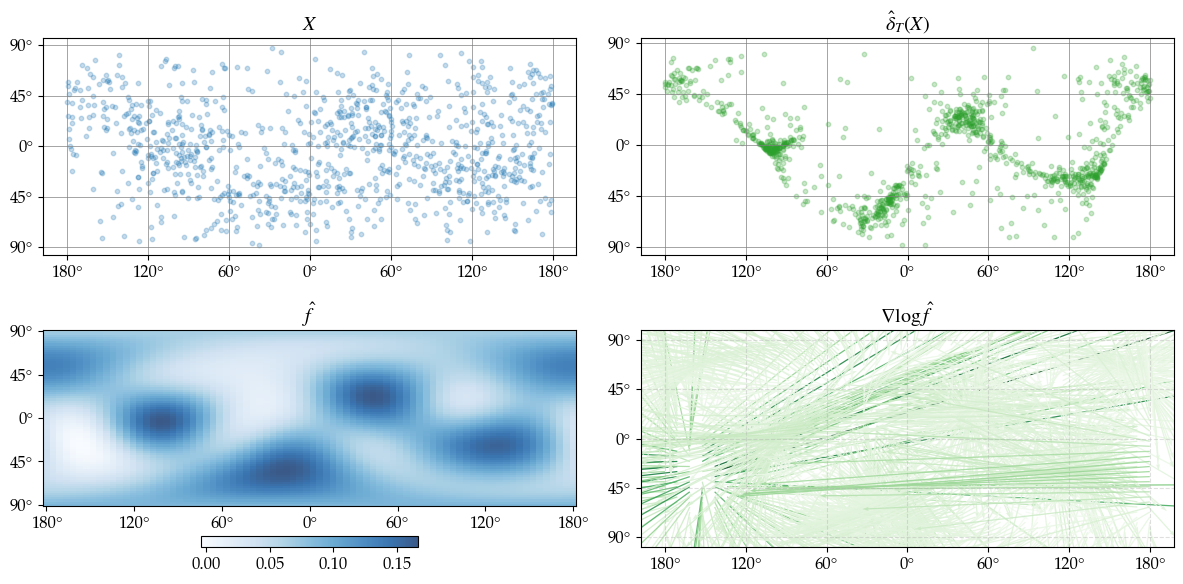

In [ ]:
res = 80
X_grid, grid_theta, grid_phi, = S2grid(res)
X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)
hat_score = hat_grad_f / np.maximum(hat_f[:, np.newaxis], rho)
delta = denoiser('S2', X, M, rho, sigma2, X)


fig, axs = plt.subplots(2, 2, figsize=(12, 6), 
                        # subplot_kw={'projection': 'mollweide'}
                        )

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
S2scatter(X, ax=axs[0, 0], color='C0', alpha=0.25, s=10)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].set_title('$\\hat{\\delta}_T(X)$')
S2scatter(delta, ax=axs[0, 1], color='C2', alpha=0.25, s=10)

# Bottom-left plot: $\hat{f}$
axs[1,0].set_title(r'$\hat f$')
im_f = axs[1,0].pcolormesh((grid_phi - np.pi), (np.pi/2 - grid_theta), # in mollwide!
                        hat_f.reshape(res, res),
                        alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[1,0], orientation='horizontal', fraction=0.05, pad=0.14)

# Bottom-right plot: $\nabla \log \hat{f}$ 

_X_grid = S2grid(40)[0]; 
_X_grid, _hat_f, _hat_grad_f = density_estimate('S2', X, M, _X_grid)
# _score = np.zeros_like(_hat_grad_f)
# np.divide(
#     _hat_grad_f,
#     np.maximum(_hat_f, rho)[:, None],
#     out=_score,
#     where=_hat_f[:, None] >= rho + 1e-1
# )
_score = _hat_grad_f/np.maximum(_hat_f, rho)[:, None]

vals_to_plot =  {   'gradient': {'vals': _hat_grad_f, 'cmap' : 'Blues', 'title' : r'$\nabla \hat f$' },
                    'score': {'vals': _score, 'cmap' : 'Greens', 'title' : r'$\nabla \log \hat f$' }}
WHICH = 'score' # 'gradient' or 'score'

S2plot_quiver(_X_grid , vals_to_plot[WHICH]['vals'], 
              figax= (fig,axs[1,1]), scale=1, cmap = vals_to_plot[WHICH]['cmap'])
axs[1,1].set_title(vals_to_plot[WHICH]['title'])

for ax in axs.flatten():   
    ax.set_xticks(np.linspace(-np.pi, np.pi, 7))
    ax.set_xticklabels(['180°', '120°', '60°', '0°', '60°', '120°', '180°'])
    ax.set_yticks(np.linspace(-np.pi/2, np.pi/2, 5))
    ax.set_yticklabels(['90°', '45°', '0°', '45°', '90°'])

plt.tight_layout()
plt.show()



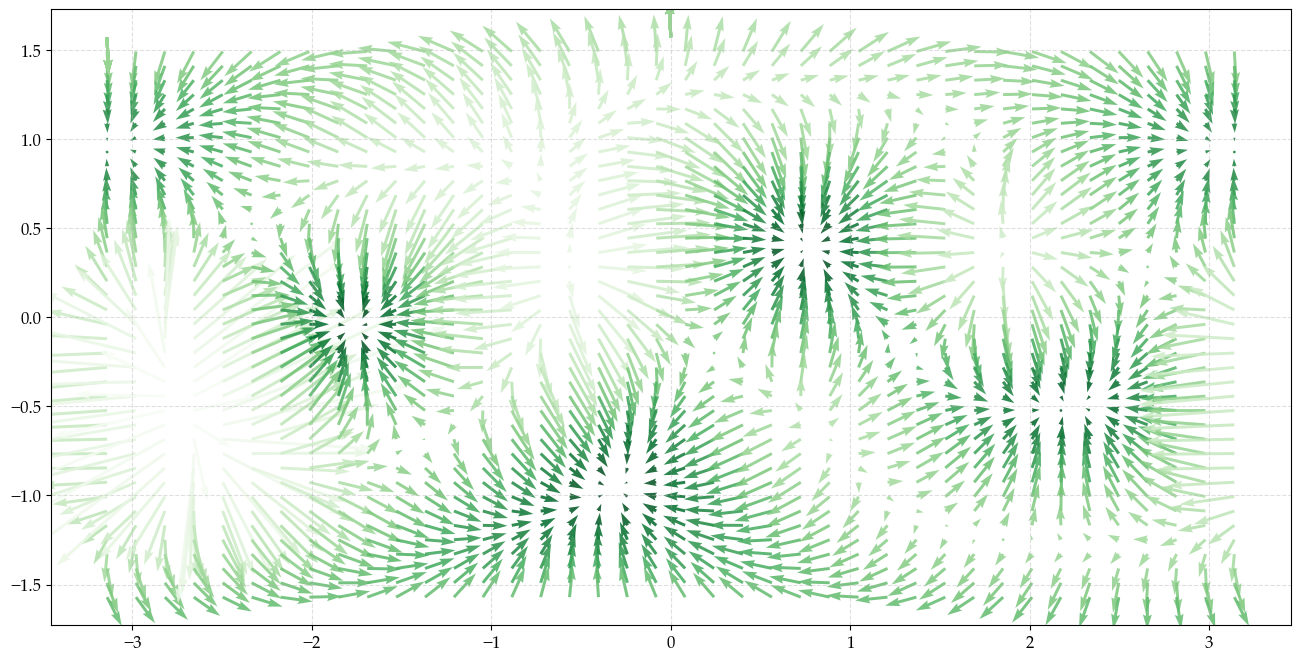

In [50]:
fig, ax = plt.subplots(figsize=(16, 8))
S2plot_quiver(_X_grid , vals_to_plot[WHICH]['vals'], 
               figax = (fig,ax), scale=10, cmap = vals_to_plot[WHICH]['cmap'], cvals = _hat_f)

In [ ]:
if False:
    # Single figure: 2 on top, 3 on bottom
    fig, axs = plt.subplots(2, 3, figsize=(20, 10), subplot_kw={'projection': 'mollweide'})

    # --- top row (use first two axes, use the third for a text panel) ---
    S2scatter(Theta, axs[0, 0], color='C1', alpha=0.25)
    axs[0, 0].set_title(r'$\Theta$')

    S2scatter(X, axs[0, 1], color='C0', alpha=0.25)
    axs[0, 1].set_title(rf'$X$' + '\n' + f'({loss_N:.2f})')

    # --- top-right: info panel ---
    axs[0, 2].set_axis_off()
    info = (
        f"n_samples = {n_samples}\n\n"
        f"# prior parameters\n"
        f"num_modes = {num_modes}\n"
        f"tau2 = {tau2}\n\n"
        f"# noise variance\n"
        f"sigma2 = {sigma2}\n\n"
        f"# for empirical density estimation\n"
        f"M = {M}\n"
        f"rho = {rho}\n\n"
        f"# for oracle approximation\n"
        f"num_oracle_samples = {num_oracle_samples}\n"
        f"oracle_bandwidth = {oracle_bandwidth}"
    )
    axs[0, 2].text(
        0.0, 1.0, info,
        transform=axs[0, 2].transAxes,
        va="top", ha="left",
        fontsize=12, family="monospace"
    )

    # --- bottom row (three denoisers) ---
    S2scatter(delta, axs[1, 0], color='C2', alpha=0.25)
    axs[1, 0].set_title(rf'$\hat\delta$' + '\n' + f'({loss_T:.2f})')
    S2scatter(oracle_delta_T, axs[1, 1], color='C3', alpha=0.25)
    axs[1, 1].set_title(rf'$\delta$ (oracle)' + '\n' + f'({loss_oracle_T:.2f})')

    S2scatter(oracle_delta_B, axs[1, 2], color='C4', alpha=0.25)
    axs[1, 2].set_title(rf'Bayes (oracle)' + '\n' + f'({loss_oracle_B:.2f})')

    plt.savefig('denoising_S2.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [ ]:
grid_resolution = 50
grid, grid_theta, grid_phi = S2grid(grid_resolution)
_, hat_f, hat_grad_f, = density_estimate('S2', X, M, grid)
hat_grad_f = np.where(hat_f[:, None] > rho, hat_grad_f, np.zeros_like(hat_grad_f))

fig, axs = plt.subplots(1, 3, figsize=(20, 5), 
                        # subplot_kw={'projection': 'mollweide'}
                        )
skip = 1
S2plot_quiver(fig, {'f' : hat_f, 'grad_f' : hat_grad_f}, rho, 'gradient', axs[1], skip = skip, grid_resolution = grid_resolution, scale =1)
S2plot_quiver(fig, {'f' : hat_f, 'grad_f' : hat_grad_f}, rho, 'score', axs[2], skip = skip, grid_resolution = grid_resolution, scale =1)
im = axs[0].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Blues')
fig.colorbar(im, ax= axs[0], orientation='horizontal', fraction=0.05, pad=0.04)
axs[0].grid(True, color='gray', lw=0.5)


----

In [ ]:
n_samples = 1000000
G =lambda n: uniform_sampler(manifold_type, n ) 

Theta =G(n_samples)
sigma2s = np.logspace(-15,-1)
losses = np.zeros_like(sigma2s)
for ix, sigma2 in tqdm(enumerate(sigma2s), total=len(sigma2s)):
    X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
    naive_loss = sq_loss(manifold, X, Theta)
    losses[ix] = naive_loss


plt.show()

In [ ]:
resid = losses - 2*sigma2s
mask = resid > 1e-16  # needed for log

sigma2_max = 1
mask = (sigma2s <= sigma2_max) & (resid > 0)

xs = np.log(sigma2s[mask])
ys = np.log(resid[mask])

# linear fit: ys ≈ a + p*xs
p, a = np.polyfit(xs, ys, 1)  # slope=p, intercept=a
C = np.exp(a)
# p = np.dot(xs, ys) / np.dot(xs, xs)
# a = 0.0
# C = 1.0

print(f"estimated p ≈ {p:.4f}, C ≈ {C:.4e}, using {mask.sum()} points")

# plot
plt.figure()
plt.loglog(sigma2s, np.abs(resid), "o-", label="|loss - sigma^2|")
plt.loglog(
    sigma2s[mask],
    C * (sigma2s[mask] ** p),
    "--",
    label=f"fit: C*sigma2^p (p={p:.2f})",
)
plt.xlabel("sigma^2")
plt.ylabel("residual loss")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [ ]:
if False:
    M_grid=np.arange(1, 13)
    rho_grid = None # np.logspace(-8, -2, 20) 
    criterion = 'AIC'
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))
    params_density, cv_scores_density = DensityKFoldCV(manifold_type, X, M_grid, None, n_splits=10, return_scores=True, random_state=42)
    plot_cv_scores(cv_scores_density[criterion], M_grid, rho_grid, ax= axs[0], 
                        title=f"Density cv {params_density[criterion]}")

    from matplotlib.lines import Line2D
    handles1, handles2 = [],[]
    for rho_percentile in [1,2,3,4,5]:
        params_scoreMatching , cv_scores_scoreMatching =  scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=10, return_scores=True, random_state=42, rho_percentile = rho_percentile)
        plot_cv_scores(cv_scores_scoreMatching[criterion], M_grid, rho_grid, ax= axs[1], 
                            title=f"Score Matching cv {params_scoreMatching[criterion]}")
        
        params_scoreMatching , cv_scores_scoreMatching =  scoreMatching(manifold_type, X, M_grid, None, eval_grid = None, return_scores=True, rho_percentile = rho_percentile)
        handles1.append(Line2D([0], [0], color=f"C{rho_percentile-1}", lw=3, label=f"rho percentile = {rho_percentile} | M : {params_scoreMatching[criterion][0]}"))
        
        plot_cv_scores(cv_scores_scoreMatching[criterion], M_grid, rho_grid,ax = axs[2], 
                            title=f"Score Matching cv {params_scoreMatching[criterion]}")
        handles2.append(Line2D([0], [0], color=f"C{rho_percentile-1}", lw=3, label=f"rho percentile = {rho_percentile} | M : {params_scoreMatching[criterion][0]}"))
    axs[1].legend(handles=handles1, title="Score matching (CV)", loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=True, ncol=2,)
    axs[2].legend(handles=handles2, title="Score matching", loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=True, ncol=2,)
    plt.tight_layout()


